In [22]:
import numpy as np
import matplotlib.pyplot as plt
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [23]:
header = "D:/K_sunada/database/"

## ac stark shift

result

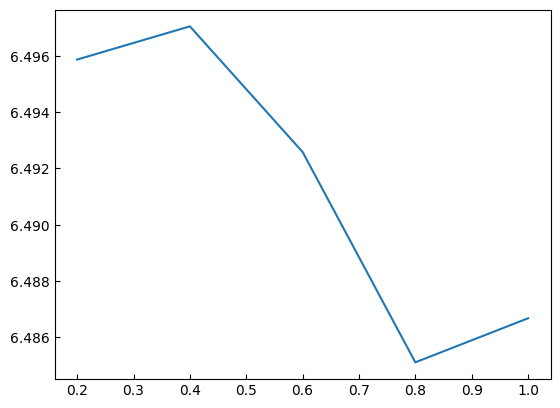

In [24]:
x = [0.2, 0.4, 0.6, 0.8, 1.0]
y = [6.49587039, 6.49705176, 6.49258303, 6.48510327, 6.48667081]

plt.plot(x, y)
plt.show()

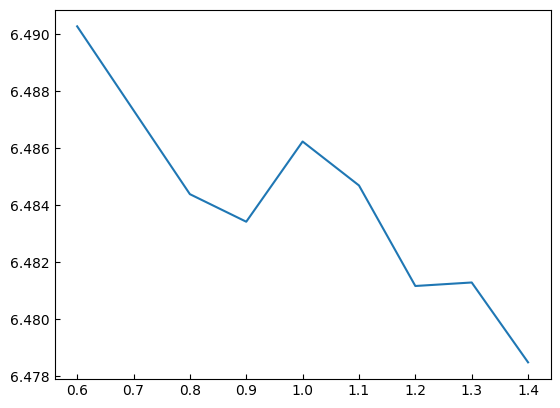

In [25]:
x =[0.6 , 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4] #[0.2, 0.4, 0.6 , 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
y =[6.49027817, 6.48438702, 6.48341941, 6.48623481, 6.48469270, 6.48116290, 6.48128617, 6.47848298] #[6.41555167, 6.48026938	, 6.49027817, 6.48438702, 6.48341941, 6.48623481, 6.48469270, 6.48116290, 6.48128617, 6.47848298]

plt.plot(x, y)
plt.show()

In [26]:
def ac_stark(amp, const, alpha):
    return const - alpha*(amp**2)

In [27]:
par_ini = {
    'const':6.5,
    'alpha':0.02
}

par_min = {
    'const':0,
    'alpha':0
}

par_max = {
    'const':np.inf,
    'alpha':np.inf
}

par_vary = {
    'const':True,
    'alpha':True
}

In [28]:
model = lmfit.Model(ac_stark)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [29]:
result = model.fit(data = y, params=params, amp = x)
result

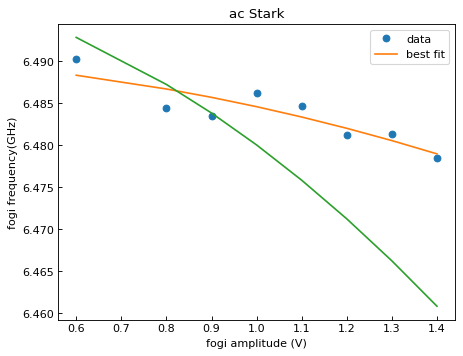

In [30]:
fig, ax = plt.subplots(dpi=80)

plt.title("ac Stark")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x ,result.init_fit)

plt.xlabel("fogi amplitude (V)")
plt.ylabel("fogi frequency(GHz)")


plt.show()

analyze

In [31]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [32]:
ac = "/2023-07-05/2023-07-05T180318_c8d49192-td_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(11):
    ini = 101*i
    fin = 101*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

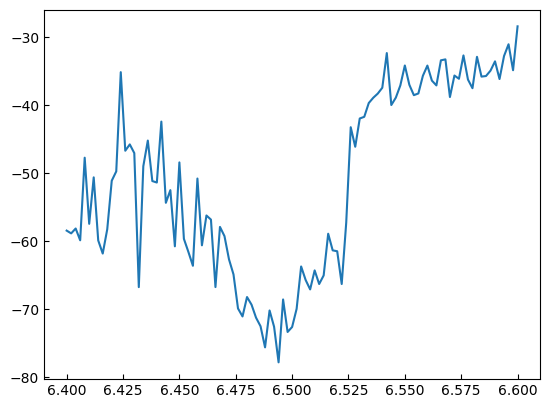

In [33]:
plt.plot(xs[1], ys[1])
plt.show()

In [34]:
par_ini = {
    'amp': 40,
    'const':-40,
    'center':6.49,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [35]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [36]:
results = []
for i in range(10):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

In [37]:
results[2]